# 7. Sulfur

Sulfur is the element where this library's diagrams earn their keep, because
sulfur's most interesting metabolism is one that a textbook Frost diagram —
drawn at unit activity, as they all are — says is impossible.

The claim to test: **elemental sulfur disproportionation**,

    4 S⁰ + 4 H₂O → 3 H₂S + SO₄²⁻ + 2 H⁺

a real metabolism run by *Desulfocapsa* and others, in which sulfur is both
the donor and the acceptor. It is famously marginal, and famously requires a
sulfide sink to run at all. We can compute exactly how marginal.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

import microbial_thermo as mt
from microbial_thermo.figures import (
    frost_diagram,
    latimer_diagram,
    plot_frost,
    plot_latimer,
    plot_pourbaix,
)

warnings.filterwarnings("ignore", category=UserWarning)

## The ladder

In [2]:
ladder = latimer_diagram("S", pH=7.0)
ladder.to_frame()

,oxidized,reduced,n electrons,E (V),dG (kJ/mol element),half reaction
0,SO4--,HSO3-,2.0,-0.515213,99.420992,SO4-- + 3 H+ + 2 e- -> HSO3- + H2O
1,HSO3-,Sulfur(s),4.0,-0.041387,15.973029,HSO3- + 5 H+ + 4 e- -> Sulfur(s) + 3 H2O
2,Sulfur(s),HS-,2.0,-0.269068,51.922307,Sulfur(s) + H+ + 2 e- -> HS-


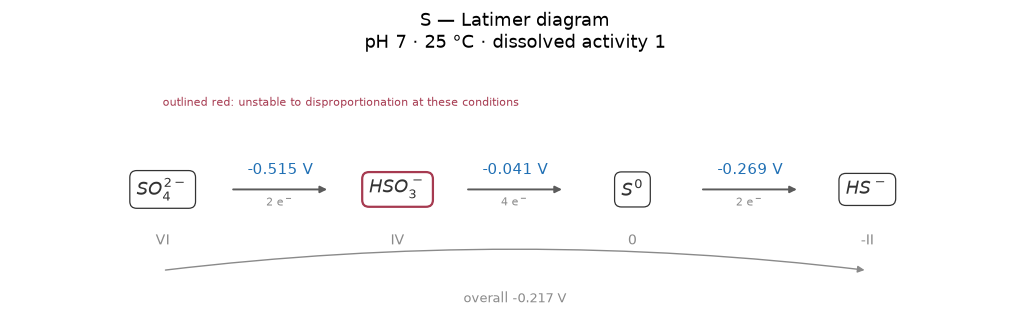

In [3]:
plot_latimer("S", diagram=ladder)
plt.show()

Every rung changes species between pH 0 and pH 7 — bisulfate to sulfate,
H₂S to HS⁻ — because sulfur's forms are acids with p*K*a values inside the
environmental range. That is the reason a sulfur diagram quoted "at standard
conditions" is nearly useless for a sediment:

In [4]:
for ph in (0.0, 2.0, 7.0, 9.0):
    steps = latimer_diagram("S", pH=ph).steps
    chain = "  ".join(f"{s.oxidized.backend} –({s.potential:+.3f})→ {s.reduced.backend}" for s in steps)
    print(f"pH {ph:4.1f}   {chain}")

pH  0.0   HSO4- –(+0.047)→ HSO3-  HSO3- –(+0.476)→ Sulfur(s)  Sulfur(s) –(+0.145)→ H2S(aq)
pH  2.0   SO4-- –(-0.072)→ HSO3-  HSO3- –(+0.328)→ Sulfur(s)  Sulfur(s) –(+0.026)→ H2S(aq)
pH  7.0   SO4-- –(-0.515)→ HSO3-  HSO3- –(-0.041)→ Sulfur(s)  Sulfur(s) –(-0.269)→ HS-
pH  9.0   SO4-- –(-0.640)→ SO3--  SO3-- –(-0.216)→ Sulfur(s)  Sulfur(s) –(-0.328)→ HS-


## Frost at unit activity: sulfur is stable

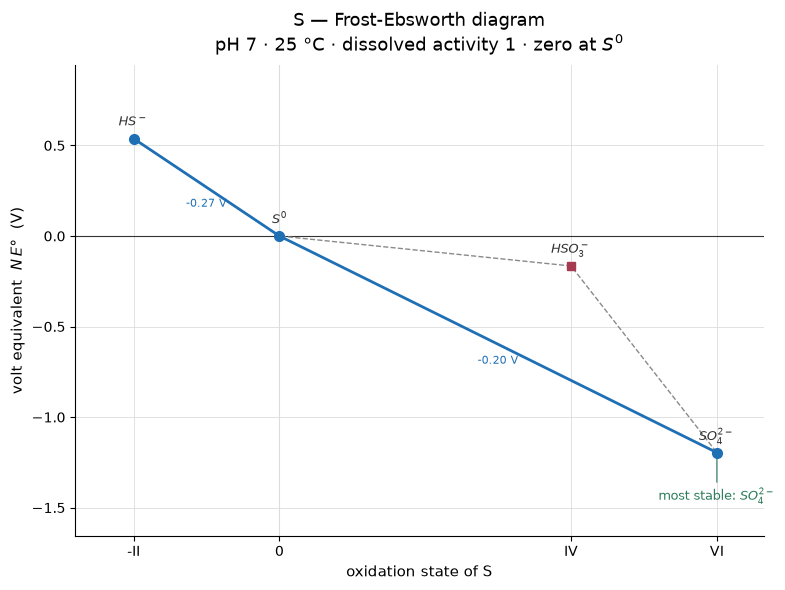

In [5]:
plot_frost("S", pH=7.0, activity=1.0, annotate_slopes=True)
plt.show()

In [6]:
textbook = frost_diagram("S", pH=7.0, activity=1.0)
print("on the hull:", [p.backend for p in textbook.stable])
for event in textbook.disproportionation():
    print(event)

on the hull: ['HS-', 'Sulfur(s)', 'SO4--']
HSO3- -> 0.667 SO4-- + 0.333 Sulfur(s)  (-61.0 kJ/mol HSO3-)


Elemental sulfur is **on the hull**. At unit activity the diagram says
disproportionation cannot happen, and every published sulfur Frost diagram
says the same thing, because every published one is drawn at unit activity.

Sulfite is above the hull, which is also true and also worth knowing:
sulfite disproportionation is itself a microbial metabolism, and a much
easier one.

## Frost at a realistic activity: sulfur is not stable

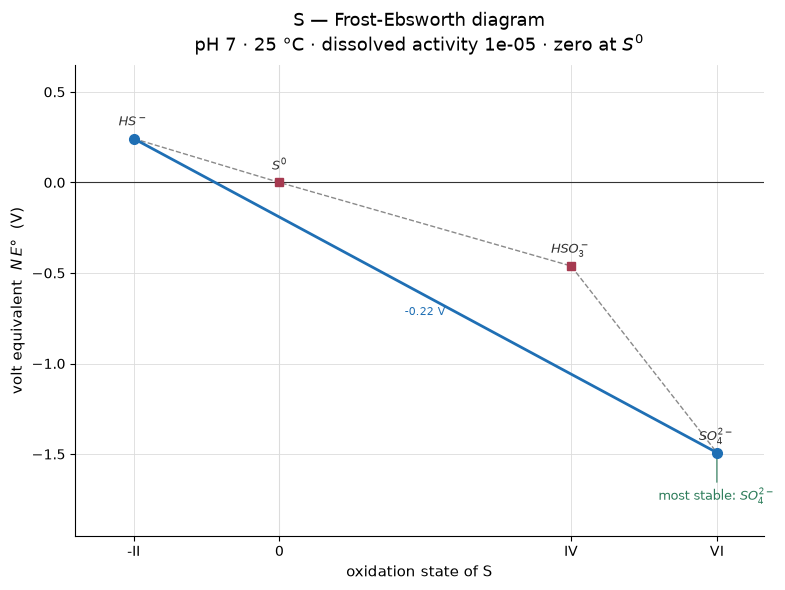

In [7]:
plot_frost("S", pH=7.0, activity=1e-5, annotate_slopes=True)
plt.show()

In [8]:
real = frost_diagram("S", pH=7.0, activity=1e-5)
print("on the hull:", [p.backend for p in real.stable])
for event in real.disproportionation():
    print(event)

on the hull: ['HS-', 'SO4--']
Sulfur(s) -> 0.25 SO4-- + 0.75 HS-  (-18.4 kJ/mol Sulfur(s))
HSO3- -> 0.75 SO4-- + 0.25 HS-  (-57.6 kJ/mol HSO3-)


Elemental sulfur has left the hull. Drop the dissolved sulfur species from
unit activity to 10 µM — an ordinary porewater — and disproportionation
becomes exergonic by about 18 kJ per mole of sulfur.

**Why lowering the activity changes the answer.** Sulfur is a solid, so its
energy does not move; the dissolved products, sulfate and sulfide, both get
cheaper as they get more dilute. The reaction makes four moles of dissolved
product from a solid, so diluting the solution pulls it forward. This is Le
Chatelier's principle, and it is the whole of the sulfur-disproportionation
story.

## Where the line is

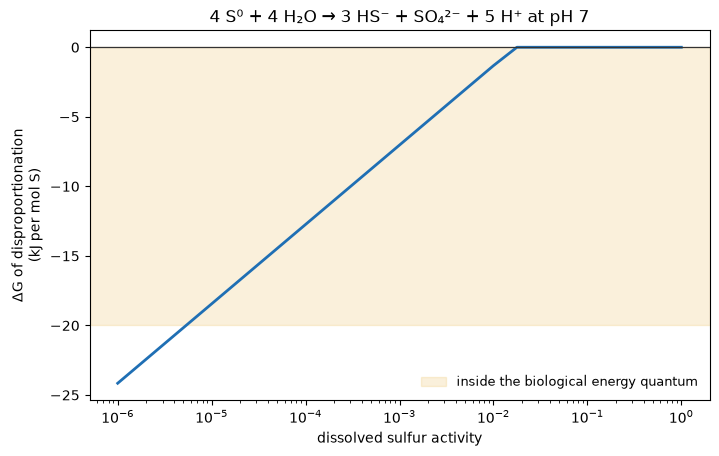

In [9]:
activities = np.logspace(-6, 0, 25)
energies = []
for activity in activities:
    diagram = frost_diagram("S", pH=7.0, activity=activity)
    found = [e for e in diagram.disproportionation() if e.species == "Sulfur(s)"]
    energies.append(found[0].delta_g if found else 0.0)

figure, ax = plt.subplots(figsize=(8.0, 4.8))
ax.semilogx(activities, energies, linewidth=2.0, color="#1F6FB4")
ax.axhspan(-20.0, 0.0, color="#E8B84B", alpha=0.2, label="inside the biological energy quantum")
ax.axhline(0.0, color="#333333", linewidth=0.9)
ax.set_xlabel("dissolved sulfur activity")
ax.set_ylabel("ΔG of disproportionation\n(kJ per mol S)")
ax.set_title("4 S⁰ + 4 H₂O → 3 HS⁻ + SO₄²⁻ + 5 H⁺ at pH 7", fontsize=12)
ax.legend(frameon=False, fontsize=9)
plt.show()

The reaction turns exergonic at about 1.7 × 10⁻², but exergonic is not the
same as *useful*: the curve stays inside the biological energy quantum — the
shaded band, roughly the least free energy thought to sustain a cell — until
the activity falls below about 5 × 10⁻⁶.

That is the quantitative version of the textbook statement that sulfur
disproportionators **need a sulfide sink**. Precipitating FeS keeps sulfide
low; keeping sulfide low is what keeps this reaction worth running. The
organism does not merely tolerate an iron-rich sediment, it requires one.

## Where each form lives

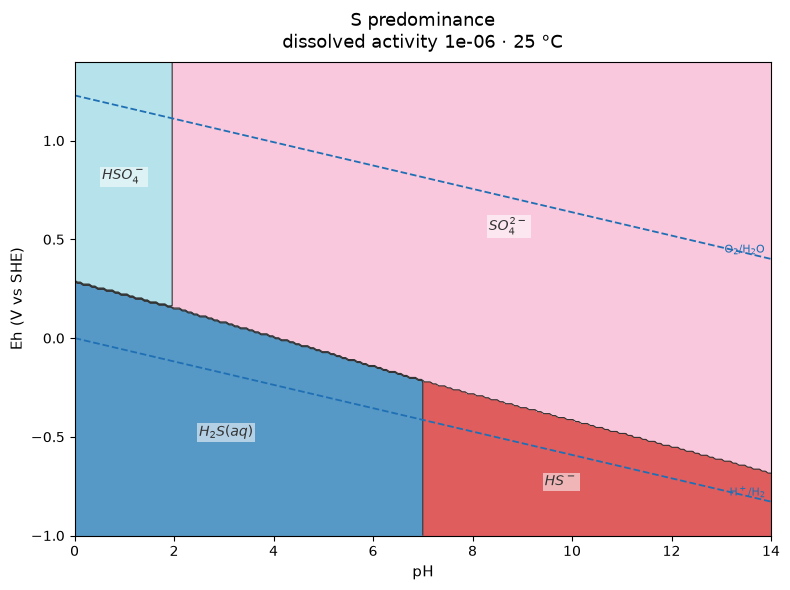

In [10]:
plot_pourbaix("S", figsize=(8.0, 6.0))
plt.show()

Note what is *not* on that diagram: elemental sulfur has no field at 10⁻⁶
activity. It is metastable everywhere, which is the same result as the Frost
curve in a different projection.

## The same thing, as a slider

Everything above is one figure with one control. Drag **activity** and watch
elemental sulfur leave the convex hull — the moment it does is the moment
disproportionation starts paying.

In [11]:
from microbial_thermo.figures import interactive_element

interactive_element("S", initial_ph=7.0, initial_log_activity=-5.0)

Start at `log₁₀(activity) = 0` — the textbook diagram, sulfur on the hull —
and drag left. Somewhere below −1.8 the S⁰ marker turns red and the note at
the bottom of the figure names the reaction it would run.

Then drag **pH** up: the disproportionation gets stronger, because the
products include protons and a rising pH pulls them away. That is the same
−59 mV per proton per electron that moves every other diagram in this
series, showing up as a metabolism becoming viable.

## Who lives on each step

In [12]:
conditions = mt.Conditions(temperature_c=25.0, pH=7.0)
sulfur = [
    "hydrogenotrophic_sulfate_reduction",
    "acetotrophic_sulfate_reduction",
    "sulfur_reduction_hydrogen",
    "sulfide_oxidation_oxygen",
    "sulfur_oxidation_oxygen",
    "sulfide_oxidation_nitrate",
    "anaerobic_methane_oxidation",
]
table = mt.energy_table(conditions).set_index("name")
table.loc[sulfur][["label", "dG per e- (kJ/mol)", "reaction"]]

Duplicate found for species "Fluorphlogopite" in supcrtbl.dat
Duplicate found for species "Arsenic" in supcrtbl.dat
Duplicate found for species "Arsenolite" in supcrtbl.dat


,label,dG per e- (kJ/mol),reaction
name,,,
hydrogenotrophic_sulfate_reduction,Hydrogenotrophic sulfate reduction,-19.041526,1/4 H+ + H2(g) + 1/4 SO4-- -> 1/4 HS- + H2O
acetotrophic_sulfate_reduction,Acetotrophic sulfate reduction,-5.080705,1/4 Acetate + 1/2 H+ + 1/4 SO4-- -> 1/2 CO2(aq...
sulfur_reduction_hydrogen,Elemental sulfur reduction with hydrogen,-13.994913,H2(g) + Sulfur(s) -> H+ + HS-
sulfide_oxidation_oxygen,Sulfide oxidation with oxygen,-103.683562,1/4 HS- + 1/2 O2(aq) -> 1/4 SO4-- + 1/4 H+
sulfur_oxidation_oxygen,Elemental sulfur oxidation with oxygen,-102.001358,1/3 Sulfur(s) + 1/3 H2O + 1/2 O2(aq) -> 1/3 SO...
sulfide_oxidation_nitrate,Sulfide oxidation with nitrate,-91.274463,1/4 HS- + 3/20 H+ + 2/5 NO3- -> 1/4 SO4-- + 1/...
anaerobic_methane_oxidation,Anaerobic oxidation of methane with sulfate,-3.687292,1/4 Methane(aq) + 1/4 H+ + 1/4 SO4-- -> 1/4 CO...


### The disproportionations, as named metabolisms

The three reactions this notebook has been circling are in the curated
library, and they are the only entries in it where the donor and the
acceptor are the same element:

In [13]:
table.loc[
    [
        "sulfur_disproportionation",
        "sulfite_disproportionation",
        "thiosulfate_disproportionation",
    ]
][["label", "dG per e- (kJ/mol)", "reaction"]]

,label,dG per e- (kJ/mol),reaction
name,,,
sulfur_disproportionation,Elemental sulfur disproportionation,6.728817,4/3 Sulfur(s) + 4/3 H2O -> 1/3 SO4-- + 5/3 H+ ...
sulfite_disproportionation,Sulfite disproportionation,-39.176376,4/3 SO3-- + 1/3 H+ -> SO4-- + 1/3 HS-
thiosulfate_disproportionation,Thiosulfate disproportionation,-3.172235,1/2 S2O3-- + 1/2 H2O -> 1/2 SO4-- + 1/2 H+ + 1...


**The +6.7 on the first row is the same result as the Frost diagram**, by a
completely different route: the library balanced two half reactions and
looked up formation energies, while the diagram compared a point to a chord
on a convex hull. They agree because they are the same thermodynamics, and
the agreement is worth checking rather than assuming:

In [14]:
standard = frost_diagram("S", pH=7.0, activity=1.0)
chord_energy = [e for e in standard.disproportionation() if e.species == "Sulfur(s)"]
print("Frost diagram says:", chord_energy or "S(0) is on the hull — nothing to disproportionate")
print(f"library says:       {table.loc['sulfur_disproportionation', 'dG per e- (kJ/mol)']:+.1f} kJ/mol e-")

Frost diagram says: S(0) is on the hull — nothing to disproportionate
library says:       +6.7 kJ/mol e-


The Frost diagram says nothing, because at unit activity elemental sulfur is
*on* the hull; the library says +6.7 kJ/mol e⁻, which is the same statement
with a sign: the reaction is uphill and will not run. Take the sulfide away
and both change together.

**Sulfite is the easy one** at about −39 kJ/mol e⁻, and thiosulfate sits
between them at −3. That ordering is the reason sulfur disproportionators
were found on sulfite and thiosulfate first: those two pay without needing
anything else to happen, and elemental sulfur does not.

### Why an iron-rich sediment is the habitat

Put the pieces together. Disproportionation needs the sulfide drawn below
about 10⁻⁵ to clear the biological energy quantum. The thing that draws
sulfide down in a real sediment is **iron**, precipitating FeS and
ultimately pyrite. So the organism does not merely tolerate iron — it
requires an iron supply, and the rate of its metabolism is set by a mineral
reaction it has no control over.

This is the general shape of a lot of biogeochemistry: an organism living on
a reaction that is only viable because a *different* process is removing one
of its products. Syntrophy (notebook 02) is the same argument with hydrogen
instead of sulfide.

## One thing worth taking away

A Frost diagram is a picture of a *chosen* state, not of the element. The
activity it was drawn at is part of the claim it makes, and for sulfur the
choice flips the conclusion completely: stable at 1 M, disproportionating at
10 µM, and a living organism in the gap.

Every diagram in this library prints its conditions in the title for exactly
this reason.